In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [211]:
df=pd.read_csv("Cleaned_cafe_sales.csv")

AttributeError: 'DataFrame' object has no attribute 'to_list'

**1) LINE GRAPH FOR SALES TREND**

In [24]:
df["transaction_date"]=pd.to_datetime(df["transaction_date"])

In [208]:
daily_sales=df.groupby(df["transaction_date"].dt.month)["total_spent"].sum()
month=["Jan","Feb","Mar","Apr","May","June","July","Aug","Sept","Oct","Nov","Dec"]
print(daily_sales)

transaction_date
1      7254.0
2      6644.0
3      7216.0
4      7179.0
5      6932.5
6      7353.0
7      6877.5
8      7092.5
9      6871.0
10     7314.0
11     6967.0
12    11341.5
Name: total_spent, dtype: float64


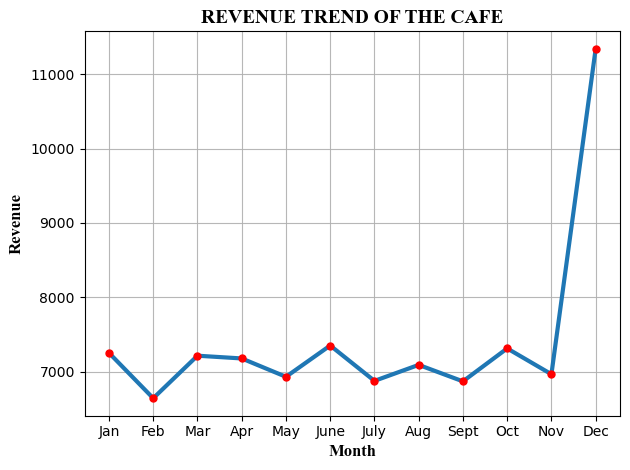

<Figure size 640x480 with 0 Axes>

In [212]:
plt.plot(month,daily_sales,
        marker="o",
        markersize=5,
        markerfacecolor="red",
        markeredgecolor="red",
        linestyle="solid",
        linewidth=3)

plt.title("REVENUE TREND OF THE CAFE",
         fontfamily="times new roman",
         fontweight="bold",
         fontsize=14
         )

plt.xlabel("Month",
         fontfamily="times new roman",
         fontweight="bold",
         fontsize=12)
plt.ylabel("Revenue",
         fontfamily="times new roman",
         fontweight="bold",
         fontsize=12)

plt.grid(alpha=0.9)
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("Revenue_Trend.png")

In [207]:
#=======================================================================================
#INSIGHT FROM THE LINE GRAPH:
#The Revenue peaks in december($11341) indicating a strong seasonal demand
#the Revenue is significantly low in february($6644) possibly dues to fewer days than others

**2) PIE CHART FOR**

In [123]:
sales_per_item=df.groupby("item")["total_spent"].sum().sort_values(ascending=True)

item
Cookie       3598.0
Tea          5475.0
Coffee       7808.0
Cake        10404.0
Juice       12786.0
Smoothie    13344.0
Sandwich    16532.0
Salad       19095.0
Name: total_spent, dtype: float64


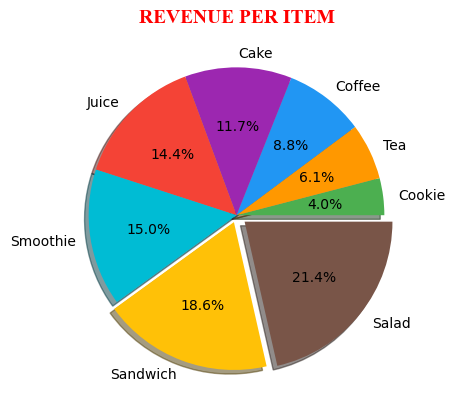

In [127]:
plt.pie(sales_per_item,labels=(sales_per_item.index),
        autopct="%1.1f%%",
        colors=["#4CAF50",  "#FF9800","#2196F3",  "#9C27B0","#F44336","#00BCD4","#FFC107", "#795548" ],
        shadow=True,
        explode=[0,0,0,0,0,0,0.05,0.07]
        )

plt.title("REVENUE PER ITEM",
         fontfamily="times new roman",
         fontweight="bold",
         fontsize=14,
         color="Red")
plt.show()

In [213]:
plt.savefig("Revenue_Contribution_By_Item.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
#=====================================================================================
#INSIGHTS FROM THE PIE CHART
#Salad hold the highest portion of the revenue that is 21.4% 
#followed by Sandwich 18.6% 
#whereaas , The lowers revenue contribution is from Cookie 4%


**3)sub plots of BAR CHART**

In [184]:
quantity_of_items=df.groupby("item")["quantity"].sum().sort_values(ascending=False)
revenue_from_items=df.groupby("item")["total_spent"].sum().sort_values(ascending=False)

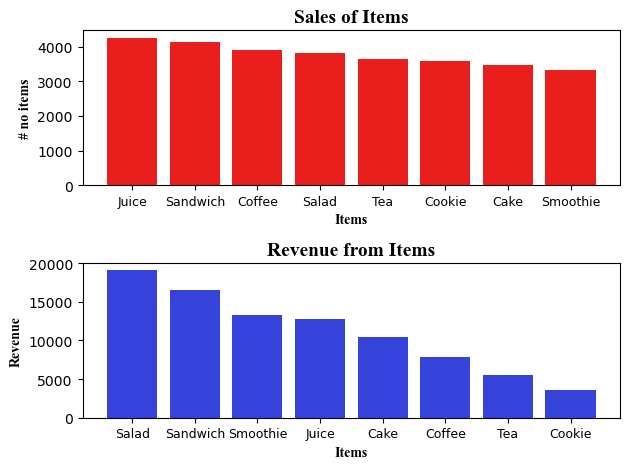

In [203]:
figs,axes=plt.subplots(2)


axes[0].bar(quantity_of_items.index,quantity_of_items,
           color="#eb1e1e")
axes[0].set_xlabel("Items",fontweight="bold",fontfamily="times new roman")
axes[0].set_ylabel("# no items",fontweight="bold",fontfamily="times new roman")
axes[0].tick_params(axis='x', labelsize=9)
axes[0].set_title("Sales of Items",fontfamily="times new roman",fontweight="bold",fontsize=14)
axes[1].bar(revenue_from_items.index,revenue_from_items,
           color="#3543db")
axes[1].set_title("Revenue from Items",fontfamily="times new roman",fontweight="bold",fontsize=14)
axes[1].set_xlabel("Items",fontweight="bold",fontfamily="times new roman")
axes[1].set_ylabel("Revenue",fontweight="bold",fontfamily="times new roman")
axes[1].tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()

In [214]:
plt.savefig("Quantity_VS_Revenue.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
#========================================================================================
#INSIGHTS FROM THE SUBPLOT
#The juice has the highest amount of sales but its impact on the revenue is proportionatly lower
#The highest revenue is from the salad even after lesser sales 

**4) HISTOGRAM**

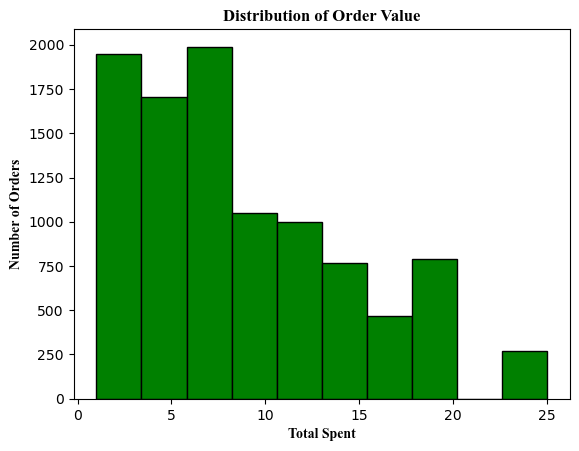

In [206]:
plt.hist(df["total_spent"],
         bins=10,
         color="green",
         edgecolor="black"
        )
plt.title("Distribution of Order Value",fontweight="bold",color="black",fontfamily="times new roman")
plt.xlabel("Total Spent",fontweight="bold",color="black",fontfamily="times new roman")
plt.ylabel("Number of Orders",fontweight="bold",color="black",fontfamily="times new roman")


plt.show()

In [215]:
plt.savefig("Distribution_Of_Order_Values.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
#=======================================================================================
#INSIGHTS FROM THE HISTOGRAM
#Most orders are low-value (~₹2–₹10), with fewer high-value transactions, indicating a right-skewed distribution.
#This suggests the cafe relies more on high order volume rather than expensive purchases.